In [2]:
from src.derived.reading_times import build_rt_and_tfd

In [3]:
rt_and_tfd = build_rt_and_tfd()
rt_and_tfd

Loading data...
Computing answer-region TFD...
Computing answer-region RT (run-based)...
Computing paragraph-region reading times...
Saved 19436 rows to E:\QA PROJECT\programming\QA_eyetracking_workspace\data\RT_and_TFD.csv


,participant_id,TRIAL_INDEX,TimeSinceOffset_pure_question,TimeSinceOffset_normalized_question,TFD_pure_question,TFD_normalized_question,TimeSinceOffset_pure_answer_A,TimeSinceOffset_normalized_answer_A,TFD_pure_answer_A,TFD_normalized_answer_A,...,TFD_pure_outside,TFD_normalized_outside,RT_pure_distractor,RT_normalized_distractor,TFD_pure_distractor,TFD_normalized_distractor,RT_pure_critical,RT_normalized_critical,TFD_pure_critical,TFD_normalized_critical
0,l42_2070,4,165.0,41.250000,165.0,41.250000,4744.0,593.000000,1814.0,226.750000,...,8325.0,105.379747,395.0,98.750000,370.0,92.500000,4937.0,329.133333,3144.0,209.600000
1,l42_2070,5,0.0,0.000000,0.0,0.000000,1273.0,106.083333,1108.0,92.333333,...,3614.0,103.257143,3476.0,579.333333,1529.0,254.833333,10548.0,527.400000,4641.0,232.050000
2,l42_2070,6,155.0,11.923077,155.0,11.923077,2596.0,324.500000,1717.0,214.625000,...,4112.0,228.444444,1153.0,115.300000,1034.0,103.400000,5784.0,144.600000,4891.0,122.275000
3,l42_2070,7,142.0,23.666667,142.0,23.666667,4049.0,404.900000,1576.0,157.600000,...,11358.0,246.913043,21850.0,1456.666667,3672.0,244.800000,9107.0,206.977273,6057.0,137.659091
4,l42_2070,8,217.0,31.000000,217.0,31.000000,1353.0,123.000000,912.0,82.909091,...,7020.0,76.304348,0.0,0.000000,0.0,0.000000,4853.0,303.312500,1819.0,113.687500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19431,l2_324,61,178.0,16.181818,178.0,16.181818,3100.0,442.857143,753.0,107.571429,...,2121.0,64.272727,128.0,42.666667,128.0,42.666667,3351.0,104.718750,2366.0,73.937500
19432,l2_324,62,117.0,16.714286,117.0,16.714286,1260.0,180.000000,546.0,78.000000,...,2287.0,71.468750,1846.0,63.655172,1319.0,45.482759,2047.0,97.476190,1179.0,56.142857
19433,l2_324,63,169.0,56.333333,164.0,54.666667,400.0,100.000000,400.0,100.000000,...,7760.0,71.192661,4214.0,383.090909,1613.0,146.636364,5679.0,135.214286,2776.0,66.095238
19434,l2_324,64,186.0,12.400000,147.0,9.800000,956.0,79.666667,802.0,66.833333,...,5877.0,59.969388,611.0,87.285714,525.0,75.000000,6059.0,137.704545,4121.0,93.659091


### Sanity check: derived RT vs `CONFIRM_FINAL_ANSWER_RT`

Sum of `RT_pure_<region>` across the answer regions (question + four answers) should be roughly equal to the trial's `CONFIRM_FINAL_ANSWER_RT` (total time from showing answers to the confirm click). The derived sum should fall *below* confirm RT on most trials — the gap covers fixations on untracked spans, saccades, blinks, and any post-final-fixation idle time before the click.

In [4]:
import pandas as pd

from src.data_paths import HUNTERS_PROCESSED_PATH, GATHERERS_PROCESSED_PATH
from src.derived.reading_times import ANSWER_REGIONS

confirm_rt = pd.concat(
    [
        pd.read_csv(
            HUNTERS_PROCESSED_PATH,
            usecols=['participant_id', 'TRIAL_INDEX', 'CONFIRM_FINAL_ANSWER_RT'],
        ),
        pd.read_csv(
            GATHERERS_PROCESSED_PATH,
            usecols=['participant_id', 'TRIAL_INDEX', 'CONFIRM_FINAL_ANSWER_RT'],
        ),
    ],
    ignore_index=True,
).drop_duplicates(['participant_id', 'TRIAL_INDEX'])

rt_pure_cols = [f'RT_pure_{r}' for r in ANSWER_REGIONS]
derived = rt_and_tfd[['participant_id', 'TRIAL_INDEX'] + rt_pure_cols].copy()
derived['derived_total_rt'] = derived[rt_pure_cols].sum(axis=1)

cmp = derived[['participant_id', 'TRIAL_INDEX', 'derived_total_rt']].merge(
    confirm_rt, on=['participant_id', 'TRIAL_INDEX'], how='inner'
)
cmp['diff'] = cmp['derived_total_rt'] - cmp['CONFIRM_FINAL_ANSWER_RT']
cmp['ratio'] = cmp['derived_total_rt'] / cmp['CONFIRM_FINAL_ANSWER_RT']

print('Per-trial comparison (ms):')
print(cmp[['derived_total_rt', 'CONFIRM_FINAL_ANSWER_RT', 'diff', 'ratio']].describe())
print()
n = len(cmp)
over = int((cmp['diff'] > 0).sum())
low_ratio = int((cmp['ratio'] < 0.5).sum())
print(f'trials: {n}')
print(f'  derived > confirm: {over} ({over / n:.1%})')
print(f'  ratio < 0.5      : {low_ratio} ({low_ratio / n:.1%})')

cmp.sort_values('ratio').head(10)

Per-trial comparison (ms):
       derived_total_rt  CONFIRM_FINAL_ANSWER_RT          diff         ratio
count      19436.000000             19436.000000  19436.000000  19436.000000
mean        6621.949064              6708.687487    -86.738424      0.982783
std         4481.284269              4483.921868    222.715578      0.043087
min            0.000000               814.000000 -11621.000000      0.000000
25%         3876.000000              3950.750000    -85.000000      0.984717
50%         5546.000000              5620.500000    -24.000000      0.994591
75%         8049.000000              8123.250000    -17.000000      0.997264
max       126575.000000            126679.000000     -6.000000      0.999889

trials: 19436
  derived > confirm: 0 (0.0%)
  ratio < 0.5      : 23 (0.1%)


,participant_id,TRIAL_INDEX,derived_total_rt,CONFIRM_FINAL_ANSWER_RT,diff,ratio
10517,l55_157,84,0.0,3027,-3027.0,0.000000
17346,l39_299,17,51.0,6834,-6783.0,0.007463
10525,l55_157,92,64.0,5198,-5134.0,0.012312
14889,l28_495,44,157.0,10734,-10577.0,0.014626
7037,l14_43,25,200.0,11821,-11621.0,0.016919
14321,l21_366,20,138.0,7305,-7167.0,0.018891
13284,l59_546,5,120.0,5057,-4937.0,0.023729
12930,l9_491,30,131.0,5500,-5369.0,0.023818
5057,l33_391,55,193.0,6345,-6152.0,0.030418
128,l39_542,25,129.0,3466,-3337.0,0.037219


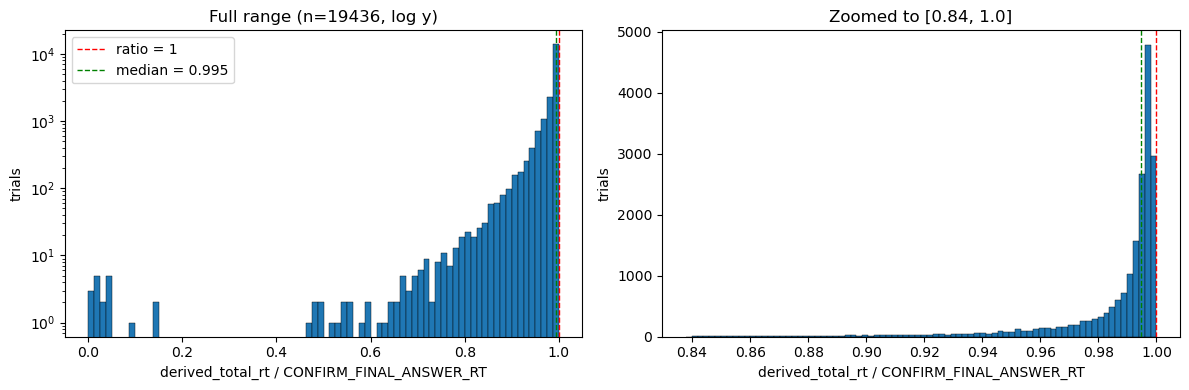

In [11]:
import matplotlib.pyplot as plt

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(12, 4))

ax_full.hist(cmp['ratio'], bins=80, edgecolor='black', linewidth=0.3)
ax_full.axvline(1.0, color='red', linestyle='--', linewidth=1, label='ratio = 1')
ax_full.axvline(cmp['ratio'].median(), color='green', linestyle='--', linewidth=1,
                label=f"median = {cmp['ratio'].median():.3f}")
ax_full.set_xlabel('derived_total_rt / CONFIRM_FINAL_ANSWER_RT')
ax_full.set_ylabel('trials')
ax_full.set_yscale('log')
ax_full.set_title(f'Full range (n={len(cmp)}, log y)')
ax_full.legend()

zoom_lo = cmp['ratio'].quantile(0.01)
ax_zoom.hist(cmp['ratio'], bins=80, range=(zoom_lo, 1.0), edgecolor='black', linewidth=0.3)
ax_zoom.axvline(1.0, color='red', linestyle='--', linewidth=1)
ax_zoom.axvline(cmp['ratio'].median(), color='green', linestyle='--', linewidth=1)
ax_zoom.set_xlabel('derived_total_rt / CONFIRM_FINAL_ANSWER_RT')
ax_zoom.set_ylabel('trials')
ax_zoom.set_title(f'Zoomed to [{zoom_lo:.2f}, 1.0]')

plt.tight_layout()
plt.show()

In [8]:
from pathlib import Path
import sys
import os

PROJECT_ROOT = Path.cwd().parent

import pandas as pd

import json
from src import constants as Con
from src.data_paths import (
    GATHERERS_FOLDS_DIR,
    GATHERERS_PROCESSED_PATH,
    HUNTERS_FOLDS_DIR,
    HUNTERS_PROCESSED_PATH,
    BUTTON_CLICKS_PATH,
)

In [ ]:
hunters = pd.read_csv(HUNTERS_PROCESSED_PATH)
gatherers = pd.read_csv(GATHERERS_PROCESSED_PATH)
all_participants = pd.concat([hunters, gatherers], ignore_index=True)



In [9]:
button_clicks = pd.read_csv(BUTTON_CLICKS_PATH)

In [7]:
all_participants[(all_participants['participant_id'] == 'l55_157') & (all_participants['TRIAL_INDEX'] == 84)]

,index,TRIAL_INDEX,participant_id,EYE_REPORTED,EYE_TRACKED,IA_AREA,IA_AVERAGE_FIX_PUPIL_SIZE,IA_BOTTOM,IA_DWELL_TIME,IA_DWELL_TIME_%,...,TFD_pure_outside,TFD_normalized_outside,RT_pure_distractor,RT_normalized_distractor,TFD_pure_distractor,TFD_normalized_distractor,RT_pure_critical,RT_normalized_critical,TFD_pure_critical,TFD_normalized_critical
414902,34552,84,l55_157,RIGHT,Right,8208.0,NaN,261,0,0.0,...,12640.0,106.218487,777.0,70.636364,648.0,58.909091,6054.0,232.846154,4428.0,170.307692
414903,34553,84,l55_157,RIGHT,Right,8208.0,NaN,261,0,0.0,...,12640.0,106.218487,777.0,70.636364,648.0,58.909091,6054.0,232.846154,4428.0,170.307692
414904,34554,84,l55_157,RIGHT,Right,10260.0,NaN,261,0,0.0,...,12640.0,106.218487,777.0,70.636364,648.0,58.909091,6054.0,232.846154,4428.0,170.307692
414905,34555,84,l55_157,RIGHT,Right,14364.0,NaN,261,0,0.0,...,12640.0,106.218487,777.0,70.636364,648.0,58.909091,6054.0,232.846154,4428.0,170.307692
414906,34556,84,l55_157,RIGHT,Right,14364.0,NaN,261,0,0.0,...,12640.0,106.218487,777.0,70.636364,648.0,58.909091,6054.0,232.846154,4428.0,170.307692
414907,34557,84,l55_157,RIGHT,Right,6156.0,NaN,261,0,0.0,...,12640.0,106.218487,777.0,70.636364,648.0,58.909091,6054.0,232.846154,4428.0,170.307692
414908,34558,84,l55_157,RIGHT,Right,8208.0,NaN,261,0,0.0,...,12640.0,106.218487,777.0,70.636364,648.0,58.909091,6054.0,232.846154,4428.0,170.307692
414909,34559,84,l55_157,RIGHT,Right,20628.0,NaN,261,0,0.0,...,12640.0,106.218487,777.0,70.636364,648.0,58.909091,6054.0,232.846154,4428.0,170.307692
414910,34560,84,l55_157,RIGHT,Right,6327.0,NaN,492,0,0.0,...,12640.0,106.218487,777.0,70.636364,648.0,58.909091,6054.0,232.846154,4428.0,170.307692
414911,34561,84,l55_157,RIGHT,Right,8436.0,NaN,492,0,0.0,...,12640.0,106.218487,777.0,70.636364,648.0,58.909091,6054.0,232.846154,4428.0,170.307692


In [10]:
button_clicks[(button_clicks['participant_id'] == 'l55_157') & (button_clicks['TRIAL_INDEX'] == 84)]

,participant_id,TRIAL_INDEX,ALL_ANSWERS,ALL_ANSWERS_LIST,PREV_ALL_ANSWERS_LIST,TRIAL_ANSWERS,SELECT_ANS_TIMESTAMPS,FIXATION_TIMESTAMPS_IA,CONFIRM_TIMESTAMPS,ANSWER_PRESS_NUMBER,LAST_FIXATIONS_BEFORE_SELECT,LAST_FIXATIONS_BEFORE_CONFIRM,NUM_OF_SELECTS_derived
19670,l55_157,84,NaN,NaN,NaN,NaN,NaN,"[(29687, 4)]",[29860],1,[],"[(29687, 4)]",0
